In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

vendor_ml_model = pd.read_csv(
    "data/vendor_ml_model.csv"
)

print("Shape:", vendor_ml_model.shape)
vendor_ml_model.head()

Shape: (126, 18)


,VendorNumber,VendorName,TotalSalesDollars,TotalPurchaseDollars,TotalSalesQuantity,TotalPurchaseQuantity,TotalSalesPrice,TotalExciseTax,GrossProfit,PurchasePrice,ActualPrice,Volume,ProfitMargin,StockTurnover,SalestoPurchaseRatio,LogSales,ProfitMargin_Capped,StockTurnover_Capped
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",1265.58,5630.88,42.0,328.0,745.74,2.52,-4365.30,20.430000,30.99,456.250000,-344.924857,0.128049,0.224757,7.144076,-258.635439,0.220430
1,60,ADAMBA IMPORTS INTL INC,67576.22,76770.25,3978.0,4732.0,42177.18,7261.07,-9194.03,12.936667,16.99,1416.666667,-13.605422,0.840659,0.880240,11.121026,-13.605422,0.840659
2,105,ALTAMAR BRANDS LLC,15706.81,11706.20,319.0,332.0,13007.39,251.59,4000.61,29.480000,39.99,750.000000,25.470544,0.960843,1.341751,9.661913,25.470544,0.960843
3,200,AMERICAN SPIRITS EXCHANGE,1719.97,1205.16,103.0,132.0,463.68,11.53,514.81,8.630000,12.99,750.000000,29.931336,0.780303,1.427171,7.450643,29.931336,0.780303
4,287,APPOLO VINEYARDS LLC,1616.92,2399.70,108.0,230.0,1472.52,11.90,-782.78,10.435000,15.49,750.000000,-48.411795,0.469565,0.673801,7.388897,-48.411795,0.469565


In [9]:
vendor_ml_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           126 non-null    int64  
 1   VendorName             126 non-null    object 
 2   TotalSalesDollars      126 non-null    float64
 3   TotalPurchaseDollars   126 non-null    float64
 4   TotalSalesQuantity     126 non-null    float64
 5   TotalPurchaseQuantity  126 non-null    float64
 6   TotalSalesPrice        126 non-null    float64
 7   TotalExciseTax         126 non-null    float64
 8   GrossProfit            126 non-null    float64
 9   PurchasePrice          126 non-null    float64
 10  ActualPrice            126 non-null    float64
 11  Volume                 126 non-null    float64
 12  ProfitMargin           126 non-null    float64
 13  StockTurnover          126 non-null    float64
 14  SalestoPurchaseRatio   126 non-null    float64
 15  LogSal

In [10]:
vendor_ml_model.isna().sum()

VendorNumber             0
VendorName               0
TotalSalesDollars        0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalPurchaseQuantity    0
TotalSalesPrice          0
TotalExciseTax           0
GrossProfit              0
PurchasePrice            0
ActualPrice              0
Volume                   0
ProfitMargin             0
StockTurnover            0
SalestoPurchaseRatio     0
LogSales                 0
ProfitMargin_Capped      0
StockTurnover_Capped     0
dtype: int64

In [11]:
vendor_ml_model.duplicated().sum()

0

In [12]:
vendor_ml_model['VendorNumber'].nunique()

124

In [13]:
vendor_ml_model[
    vendor_ml_model['VendorNumber'].duplicated(keep=False)
].sort_values('VendorNumber')

,VendorNumber,VendorName,TotalSalesDollars,TotalPurchaseDollars,TotalSalesQuantity,TotalPurchaseQuantity,TotalSalesPrice,TotalExciseTax,GrossProfit,PurchasePrice,ActualPrice,Volume,ProfitMargin,StockTurnover,SalestoPurchaseRatio,LogSales,ProfitMargin_Capped,StockTurnover_Capped
18,1587,VINEYARD BRANDS INC,1842143.10,1196162.81,166087.0,171919.0,832889.17,18425.68,645980.29,16.006338,24.419577,762.323944,35.066781,0.966077,1.540044,14.426441,35.066781,0.966077
19,1587,VINEYARD BRANDS LLC,4323.96,10951.51,104.0,371.0,3049.32,6.28,-6627.55,51.900000,77.656667,500.000000,-153.275007,0.280323,0.394828,8.372158,-153.275007,0.280323
25,2000,SOUTHERN GLAZERS W&S OF NE,40440.12,40803.92,3288.0,4198.0,16927.50,367.00,-363.80,48.474444,73.434444,750.000000,-0.899602,0.783230,0.991084,10.607602,-0.899602,0.783230
26,2000,SOUTHERN WINE & SPIRITS NE,5704567.52,3699813.46,397315.0,402677.0,2605722.64,50740.35,2004754.06,46.502117,70.222822,787.564417,35.142963,0.986684,1.541853,15.556778,35.142963,0.986684


In [14]:
vendor_ml_model[
    vendor_ml_model['VendorNumber'].duplicated(keep=False)
].T

,18,19,25,26
VendorNumber,1587,1587,2000,2000
VendorName,VINEYARD BRANDS INC,VINEYARD BRANDS LLC,SOUTHERN GLAZERS W&S OF NE,SOUTHERN WINE & SPIRITS NE
TotalSalesDollars,1842143.1,4323.96,40440.12,5704567.52
TotalPurchaseDollars,1196162.81,10951.51,40803.92,3699813.46
TotalSalesQuantity,166087.0,104.0,3288.0,397315.0
TotalPurchaseQuantity,171919.0,371.0,4198.0,402677.0
TotalSalesPrice,832889.17,3049.32,16927.5,2605722.64
TotalExciseTax,18425.68,6.28,367.0,50740.35
GrossProfit,645980.29,-6627.55,-363.8,2004754.06
PurchasePrice,16.006338,51.9,48.474444,46.502117


If we merge those into one row just because the number is the same, we would destroy meaningful information...so keeping this would be safe

In [15]:
vendor_ml_model[
    ['VendorNumber', 'VendorName']
].drop_duplicates().shape[0]

126

In [16]:
vendor_ml_model.duplicated(
    subset=['VendorNumber', 'VendorName']
).sum()

0

In [24]:
print("1588 exists:", (vendor_ml_model['VendorNumber'] == 1588).any())
print("2001 exists:", (vendor_ml_model['VendorNumber'] == 2001).any())

1588 exists: False
2001 exists: False


In [25]:
vendor_ml_model.loc[
    (vendor_ml_model['VendorNumber'] == 1587) &
    (vendor_ml_model['VendorName'] == 'VINEYARD BRANDS LLC'),
    'VendorNumber'
] = 1588

vendor_ml_model.loc[
    (vendor_ml_model['VendorNumber'] == 2000) &
    (vendor_ml_model['VendorName'] == 'SOUTHERN GLAZERS W&S OF NE'),
    'VendorNumber'
] = 2001

In [26]:
vendor_ml_model[
    vendor_ml_model['VendorNumber'].isin([1587, 1588, 2000, 2001])
][['VendorNumber', 'VendorName']]

,VendorNumber,VendorName
18,1587,VINEYARD BRANDS INC
19,1588,VINEYARD BRANDS LLC
25,2001,SOUTHERN GLAZERS W&S OF NE
26,2000,SOUTHERN WINE & SPIRITS NE


In [27]:
print("Rows:", len(vendor_ml_model))
print("Unique VendorNumbers:", vendor_ml_model['VendorNumber'].nunique())

Rows: 126
Unique VendorNumbers: 126


Vendor ID normalization: Two vendor numbers were associated with multiple vendor names in the source data. Since the corresponding vendor names represented distinct records with different business metrics, unique unused identifiers (1588 and 2001) were assigned in the analytical dataset to maintain one-to-one vendor identification. Original source data was not modified.

In [29]:
vendor_ml_model.to_csv(
    "data/vendor_ml_dataset.csv",
    index=False
)

In [30]:
df = pd.read_csv(
    "data/vendor_ml_dataset.csv"
)

In [31]:
ml_features = [
    'LogSales',
    'ProfitMargin_Capped',
    'StockTurnover_Capped'
]

In [32]:
X = vendor_ml_model[ml_features].copy()

print("Shape:", X.shape)
print("\nMissing values:")
print(X.isna().sum())

print("\nSummary statistics:")
display(X.describe().T)

Shape: (126, 3)

Missing values:
LogSales                0
ProfitMargin_Capped     0
StockTurnover_Capped    0
dtype: int64

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
LogSales,126.0,12.190338,3.044298,2.771964,10.507464,12.088152,14.759566,18.045839
ProfitMargin_Capped,126.0,14.202696,55.222900,-258.635439,15.834611,26.610030,32.981165,77.466351
StockTurnover_Capped,126.0,0.998353,0.442093,0.220430,0.866475,0.967474,0.991069,2.882353


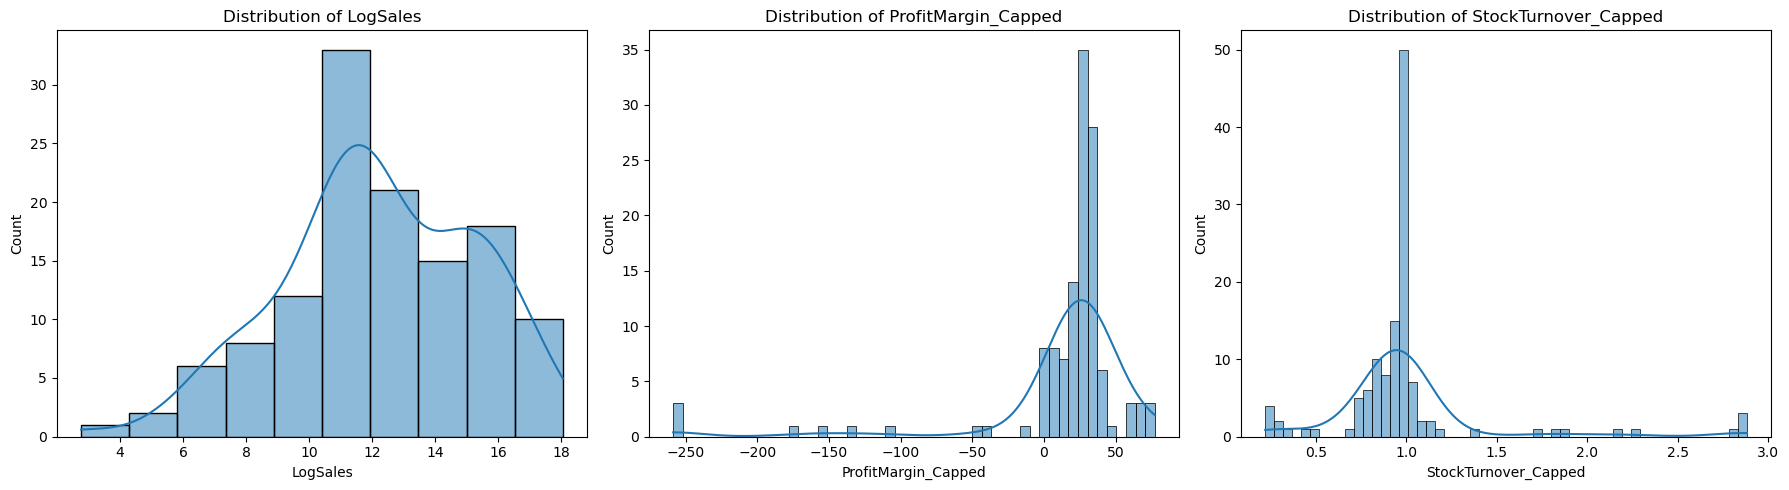

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ml_features):
    sns.histplot(X[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

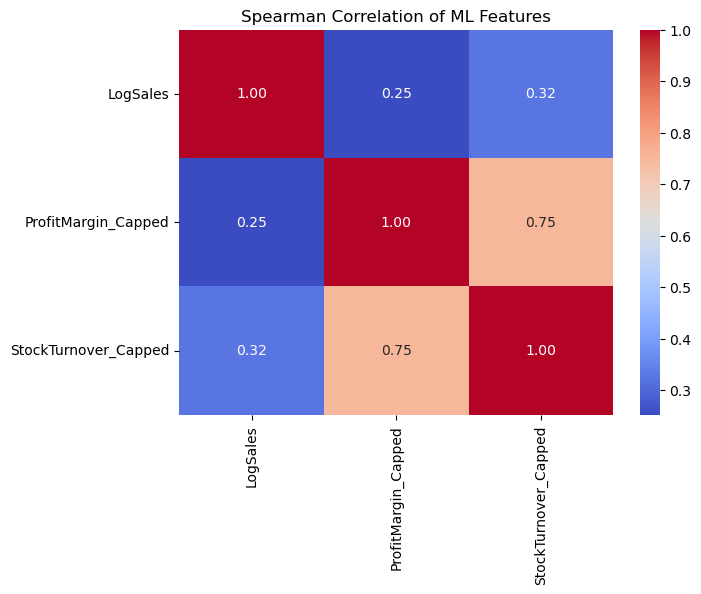

In [34]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    X.corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Spearman Correlation of ML Features")
plt.show()

In [59]:
from sklearn.preprocessing import StandardScaler, RobustScaler
# Using StandardScaler as the primary scaling method
# StandardScaler
standard_scaler = StandardScaler()

X_standard = pd.DataFrame(
    standard_scaler.fit_transform(X),
    columns=ml_features,
    index=X.index
)

print("STANDARD SCALER")
display(X_standard.describe().T)



STANDARD SCALER


,count,mean,std,min,25%,50%,75%,max
LogSales,126.0,8.652691e-16,1.003992,-3.106126,-0.555002,-0.033700,0.847317,1.931111
ProfitMargin_Capped,126.0,4.229421e-17,1.003992,-4.960393,0.029669,0.225574,0.341406,1.150179
StockTurnover_Capped,126.0,5.639228e-17,1.003992,-1.766662,-0.299494,-0.070127,-0.016541,4.278564


## Determining the Optimal Number of Clusters

K-Means clustering requires the number of clusters (K) to be specified in advance. Since the actual number of meaningful vendor segments is unknown, multiple values of K are evaluated before training the final model.

In this analysis, K values from 2 to 6 are tested using two complementary evaluation techniques:

Elbow Method using Inertia
Silhouette Score

These metrics help determine a K that provides compact and well-separated vendor segments.

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_results = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_standard)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_standard, labels)

    k_results.append({
        'K': k,
        'Inertia': inertia,
        'SilhouetteScore': silhouette
    })

k_results_df = pd.DataFrame(k_results)

display(k_results_df)

,K,Inertia,SilhouetteScore
0,2,230.841829,0.676029
1,3,119.458509,0.684343
2,4,60.695937,0.547557
3,5,48.503788,0.485216
4,6,37.247536,0.495734


Inertia measures how close the observations are to the centroid of the cluster to which they are assigned.
In K-Means, each vendor is assigned to its nearest cluster centroid. Inertia is the sum of the squared distances between each vendor and its assigned centroid.
Lower inertia indicates more compact clusters.

The Silhouette Score evaluates both the compactness of a cluster and its separation from other clusters.
For each vendor, it compares:
- the average distance to vendors within its own cluster
- the average distance to vendors in the nearest neighboring cluster

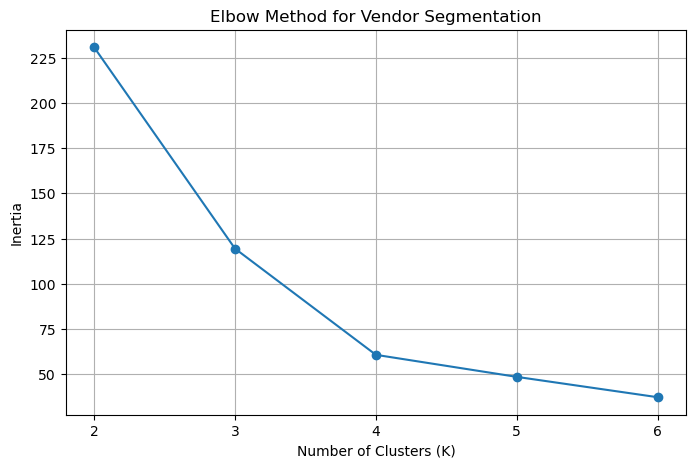

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results_df['K'],
    k_results_df['Inertia'],
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Vendor Segmentation")
plt.xticks(range(2, 7))
plt.grid(True)

plt.show()

Elbow Method

The Elbow Method is used to identify the point where increasing the number of clusters provides diminishing improvements in cluster compactness.
Inertia measures the total within-cluster squared distance between vendors and their assigned cluster centroids. As the number of clusters increases, inertia will decrease. Therefore, the objective is not to select the K with the lowest inertia, but to identify the point where the reduction in inertia begins to level off.
The point where this change becomes noticeable is referred to as the "elbow" and provides a candidate value for the optimal number of clusters.

### Observation: 
K=3 provides the best balance between cluster compactness and separation. Although inertia continues to decrease with increasing K, the improvement becomes progressively smaller, while the Silhouette Score reaches its maximum of 0.6843 at K=3 and declines thereafter. This indicates that adding more than three clusters does not improve the overall quality of the segmentation.

In [62]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

vendor_ml_model['Cluster'] = kmeans_final.fit_predict(X_standard)

print("Model Training Complete")
print(vendor_ml_model[['VendorNumber','Cluster']].head())

Model Training Complete
   VendorNumber  Cluster
0             2        2
1            60        0
2           105        0
3           200        0
4           287        0


In [63]:
cluster_counts = (
    vendor_ml_model['Cluster']
    .value_counts()
    .sort_index()
)

display(cluster_counts)

Cluster
0    110
1      9
2      7
Name: count, dtype: int64

In [64]:
centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=ml_features
)

display(centroids)

,LogSales,ProfitMargin_Capped,StockTurnover_Capped
0,0.214863,0.156597,-0.146944
1,-1.271886,0.995807,3.094719
2,-1.741136,-3.741132,-1.669803


In [65]:
vendor_ml_model.groupby('Cluster').agg({
    'VendorNumber':'count'
})

,VendorNumber
Cluster,
0,110
1,9
2,7


In [57]:
cluster_profile = vendor_ml_model.groupby('Cluster').agg(
    VendorCount=('VendorNumber','count'),
    AvgSales=('TotalSalesDollars','mean'),
    AvgProfitMargin=('ProfitMargin_Capped','mean'),
    AvgStockTurnover=('StockTurnover_Capped','mean')
).round(2)

cluster_profile

,VendorCount,AvgSales,AvgProfitMargin,AvgStockTurnover
Cluster,,,,
0,110,4103645.19,22.82,0.93
1,9,22623.89,68.98,2.36
2,7,2228.25,-191.57,0.26


## Observation

K-Means clustering with K = 3 segmented the vendors into three distinct groups. Cluster 0 contained the majority of vendors (110) with high sales and stable profitability. Cluster 1 consisted of a small group of vendors with exceptionally high profit margins and inventory turnover, while Cluster 2 included vendors with very low sales, negative profit margins, and poor stock turnover.

### Insights
- Most vendors belong to a stable, revenue-generating segment that drives overall business performance.
- A small set of vendors demonstrates strong profitability and inventory efficiency, indicating potential growth opportunities.
- A few vendors consistently underperform, resulting in low sales and financial losses.

### Business Recommendations

- Strategic Vendors (Cluster 0): Maintain strong partnerships and prioritize inventory allocation to sustain revenue growth.
- High-Margin Growth Vendors (Cluster 1): Increase purchasing volume and explore opportunities to expand business with these vendors.
- Underperforming Vendors (Cluster 2): Review contracts, pricing strategies, and inventory levels; consider vendor replacement if performance does not improv

In [66]:
import joblib

joblib.dump(kmeans_final, "kmeans_vendor_model.pkl")
joblib.dump(standard_scaler, "vendor_scaler.pkl")

['vendor_scaler.pkl']